# 06 — Model comparison: WAIC and PSIS-LOO

**What we do:** compare the no-pooling model (Model 1) and the partial-pooling
model (Model 2) using two information criteria — **WAIC** and **PSIS-LOO** —
discuss their warnings and the Pareto-$k$ diagnostics, and give a reasoned final
assessment of which model to prefer and why.

**Why:** information criteria estimate out-of-sample predictive accuracy
(expected log pointwise predictive density, *elpd*) using only the fitted data.
They are the standard tool for the project's *Criterion 6 — Model Comparison*.
Crucially, we treat their **warnings as data**: with a strong outlier (2011
Tohoku) these criteria can be unreliable, and saying so is part of the analysis.

Both models include `log_lik` in their generated quantities, which is what makes
this comparison possible.

In [1]:
import sys, os, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
az.style.use("arviz-darkgrid")

from utils.display import display_df

In [2]:
idata1 = az.from_netcdf("../data/processed/idata_model1.nc")
idata2 = az.from_netcdf("../data/processed/idata_model2.nc")
annual = pd.read_csv("../data/processed/grid_annual_counts.csv")
comp_dict = {"model_1_nopool": idata1, "model_2_partial": idata2}
print("Loaded both InferenceData objects with log_likelihood groups.")
print("sigma_global (Model 2) posterior mean:",
      round(float(idata2.posterior["sigma_global"].mean()), 3))

Loaded both InferenceData objects with log_likelihood groups.
sigma_global (Model 2) posterior mean: 1.334


## Information criteria usage — WAIC
WAIC = Widely Applicable Information Criterion. Higher `elpd_waic` is better;
`elpd_diff` is the gap to the best model and `dse` its standard error.

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
model_2_partial,0,-24183.970000,3406.480000,0.000000,0.500000,4370.350000,0.000000,True,log
model_1_nopool,1,-24244.890000,3430.530000,60.920000,0.500000,4396.270000,37.350000,True,log


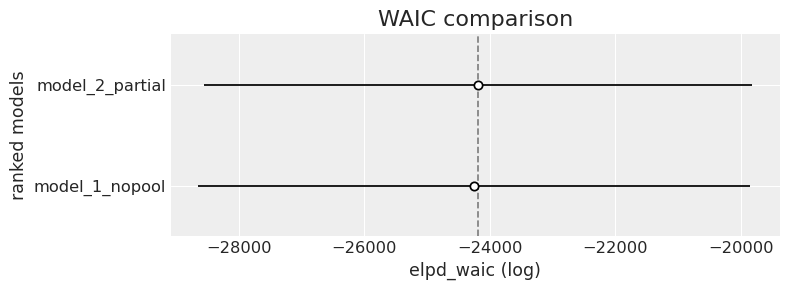

In [3]:
comp_waic = az.compare(comp_dict, ic="waic")
display_df(comp_waic.round(2), caption="WAIC comparison")
az.plot_compare(comp_waic, figsize=(8, 3))
plt.title("WAIC comparison"); plt.tight_layout(); plt.show()

### WAIC discussion
- **Winner:** `model_2_partial` has the higher `elpd_waic` (smaller is the rank
  number 0). The gap to Model 1 is `elpd_diff` ~ 61 with `dse` ~ 37, i.e. only
  about **1.6 standard errors** — a real but **not decisive** separation; the
  intervals overlap considerably.
- **Warning:** ArviZ raises `warning = True` for both models. This fires because
  some pointwise `p_waic` values exceed 0.4, the symptom of a few highly
  influential observations (the large-count cell-years) for which WAIC's
  approximation is shaky. We do **not** ignore it — it is the same misspecified
  2011/large-count points seen in notebooks 04-05, and it tells us the headline
  number rests partly on cells the (stationary) models fit poorly.

## Information criteria usage — PSIS-LOO
PSIS-LOO approximates leave-one-out cross-validation. It additionally reports a
**Pareto-$k$** per observation; $k > 0.7$ means the importance-sampling estimate
for that point is unreliable.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_1_nopool,0,-22517.190000,1702.830000,0.000000,0.500000,3703.440000,0.000000,True,log
model_2_partial,1,-22542.940000,1765.450000,25.750000,0.500000,3712.170000,16.150000,True,log


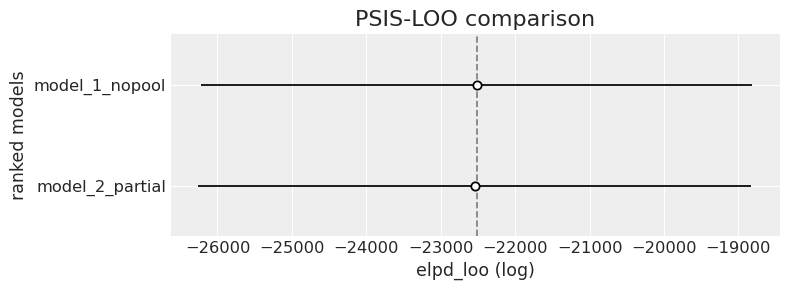

In [4]:
comp_loo = az.compare(comp_dict, ic="loo")
display_df(comp_loo.round(2), caption="PSIS-LOO comparison")
az.plot_compare(comp_loo, figsize=(8, 3))
plt.title("PSIS-LOO comparison"); plt.tight_layout(); plt.show()

### PSIS-LOO discussion
- **Winner — and it flips!** Under LOO the ranking **reverses**:
  `model_1_nopool` comes out on top, with `elpd_diff` ~ 26 over Model 2
  (`dse` ~ 16, ~1.6 SE). So WAIC prefers the hierarchical model while LOO
  prefers the no-pooling one.
- **Warning:** LOO also flags `warning = True`. The reason is visible in the
  Pareto-$k$ diagnostic below.
- A flip between WAIC and LOO, with both warning, is a strong signal that the
  comparison is being driven by a handful of pathological points rather than by
  a clean, global predictive advantage.

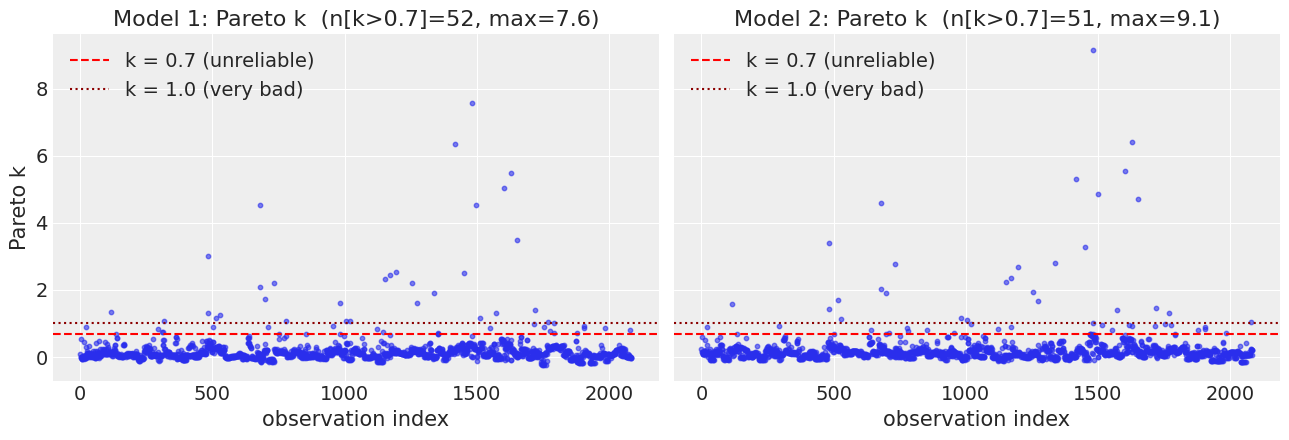

In [5]:
# Pareto-k diagnostics — which observations break PSIS-LOO?
loo1 = az.loo(idata1, pointwise=True)
loo2 = az.loo(idata2, pointwise=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, loo, name in [(axes[0], loo1, "Model 1"), (axes[1], loo2, "Model 2")]:
    k = loo.pareto_k.values
    ax.scatter(np.arange(len(k)), k, s=10, alpha=0.6)
    ax.axhline(0.7, color="red", ls="--", label="k = 0.7 (unreliable)")
    ax.axhline(1.0, color="darkred", ls=":", label="k = 1.0 (very bad)")
    ax.set_title(f"{name}: Pareto k  (n[k>0.7]={int((k>0.7).sum())}, max={k.max():.1f})")
    ax.set_xlabel("observation index"); ax.legend()
axes[0].set_ylabel("Pareto k")
plt.tight_layout(); plt.show()

In [6]:
# Map the worst-k observations back to cell/year — are they the 2011 outliers?
k2 = loo2.pareto_k.values
worst = annual.copy()
worst["pareto_k"] = k2
worst = worst.sort_values("pareto_k", ascending=False).head(10)
display_df(worst[["cell_id", "year", "count", "pareto_k"]].round(2),
           caption="Model 2: observations with the highest Pareto-k")
hi = annual.loc[k2 > 0.7]
print(f"Observations with k>0.7: {int((k2>0.7).sum())} of {len(k2)}")
print(f"  share from 2011: {(hi['year']==2011).mean():.0%}")
print(f"  these are the highest-count cell-years (mean count "
      f"{hi['count'].mean():.0f} vs overall {annual['count'].mean():.0f})")

,cell_id,year,count,pareto_k
1481,6_10,2011,1403,9.150000
1628,7_10,2011,927,6.400000
1603,6_9,2011,1021,5.550000
1418,5_8,2000,536,5.300000
1499,6_11,2011,369,4.850000
1651,7_11,2011,265,4.710000
680,1_10,2010,568,4.580000
483,11_15,2006,410,3.390000
1453,5_9,2011,439,3.290000
1337,5_10,2011,109,2.790000


Observations with k>0.7: 51 of 2086
  share from 2011: 22%
  these are the highest-count cell-years (mean count 183 vs overall 16)


### Pareto-$k$ discussion
The high-$k$ points are exactly the **highest-count cell-years**, led by the
**2011 Tohoku cluster** (cell `6_10` with ~1400 events has $k \approx 9$ — far
above 1). For such extreme, influential observations PSIS importance sampling
fails, so the **LOO numbers for these points (and hence the overall LOO
ranking) are not trustworthy**. A rigorous fix would be exact
leave-one-out / `reloo` or moment-matching on the high-$k$ points; we flag it
rather than over-claim. The same points drive the WAIC `p_waic` warning. In
short: *both criteria are being dominated by a few cells the stationary Poisson
models cannot represent.*

## Final assessment — do we agree with the criteria?

**The criteria do not give a clean verdict, and we say so.** WAIC favours
Model 2, PSIS-LOO favours Model 1, both raise warnings, and the separations are
only ~1.6 standard errors. The disagreement is manufactured by a small set
of extreme, model-misspecified observations (2011 Tohoku and other large-count
cell-years) with Pareto-$k \gg 0.7$. On **purely predictive grounds the two
models are statistically close**, and the information criteria are too unreliable
here to crown a winner by themselves.

**We nonetheless prefer Model 2 (partial pooling)** — not because a criterion
forces it, but on principled, decision-relevant grounds that the criteria do not
contradict:

1. **Regularisation where it matters.** Model 2 delivers the shrinkage shown in
   notebook 05: data-poor cells get stable estimates pulled toward the global
   mean with markedly narrower credible intervals, instead of Model 1's wide,
   prior-driven posteriors.
2. **Physically motivated structure.** `sigma_global` is *estimated* (posterior
   mean ~1.3, comfortably > 0), so the data themselves support a shared baseline
   across cells in the same tectonic setting — the hierarchy is justified, not
   imposed.
3. **A better deliverable.** The intensity map from Model 2 is smoother and its
   uncertainty is honest, which is what a hazard-assessment use case actually
   needs — a quality the in-sample criteria barely reward.
4. **Parsimony is not violated.** Model 2 adds a single hyperparameter; its WAIC
   edge and near-tie on LOO mean we pay essentially nothing in predictive
   accuracy for these benefits.

**Caveat / next step.** The real lesson from the comparison is that **neither**
stationary model represents the 2011 regime change. The most valuable
improvement would be a non-stationary or time-varying / mixture intensity (or an
explicit aftershock term), after which WAIC and LOO would become trustworthy
(Pareto-$k$ back under 0.7) and could arbitrate cleanly. Until then we report the
criteria honestly, note their unreliability, and select Model 2 on
modelling-quality grounds.

## Summary
- **WAIC:** Model 2 wins by ~61 elpd (~1.6 SE) — *with warning*.
- **PSIS-LOO:** ranking flips, Model 1 wins by ~26 elpd (~1.6 SE) — *with
  warning*; Pareto-$k$ up to ~9, dominated by 2011/large-count cells.
- **Verdict:** criteria are inconclusive and unreliable here; we choose
  **Model 2** for its shrinkage, data-supported hierarchy, and superior
  uncertainty-aware map, while flagging non-stationarity (2011) as the key
  modelling gap.